In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import wandb
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet"]:
    nltk.download(pkg, quiet=True)

### Load the Dataset

In [ ]:
train_data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
test_data  = fetch_20newsgroups(subset="test",  remove=("headers", "footers", "quotes"))

print(f"Train: {len(train_data.data)} | Test: {len(test_data.data)} | Classes: {len(train_data.target_names)}")

Train: 11314 | Test: 7532 | Classes: 20


# Pre procesisng
 1. Lowercase everything
 2. Tokenize into words
 3. Keep only alphabetic words (removes numbers, punctuation)
 4. Remove common stop words (the, is, a, ...)
 5. Lemmatize (running -> run, better -> good)

In [ ]:
def preprocess(texts):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words("english"))
    result = []
    for doc in texts:
        tokens = word_tokenize(doc.lower())
        tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
        result.append(tokens)
    return result

print("Preprocessing... (~ 1 min)")
train_tokens = preprocess(train_data.data)
test_tokens  = preprocess(test_data.data)
print("Done.")

Preprocessing... (~ 1 min)
Done.



# STEP 3: Train Word2Vec - 1 epoch vs 10 epochs (Task 1b)

### Word2Vec learns word meaning from context.
### More epochs = more training = vectors that better capture meaning.

In [ ]:
all_tokens = train_tokens + test_tokens

w2v_1  = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=2, epochs=1,  seed=42)
w2v_10 = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=2, epochs=10, seed=42)

print(f"Vocabulary: {len(w2v_1.wv)} words")

Vocabulary: 39605 words


# STEP 4: Visualize the embeddings (PCA + t-SNE)

### We pick the 200 most common words and plot where they sit in 2D space.
### If the vectors changed with more training, the clusters will look different.

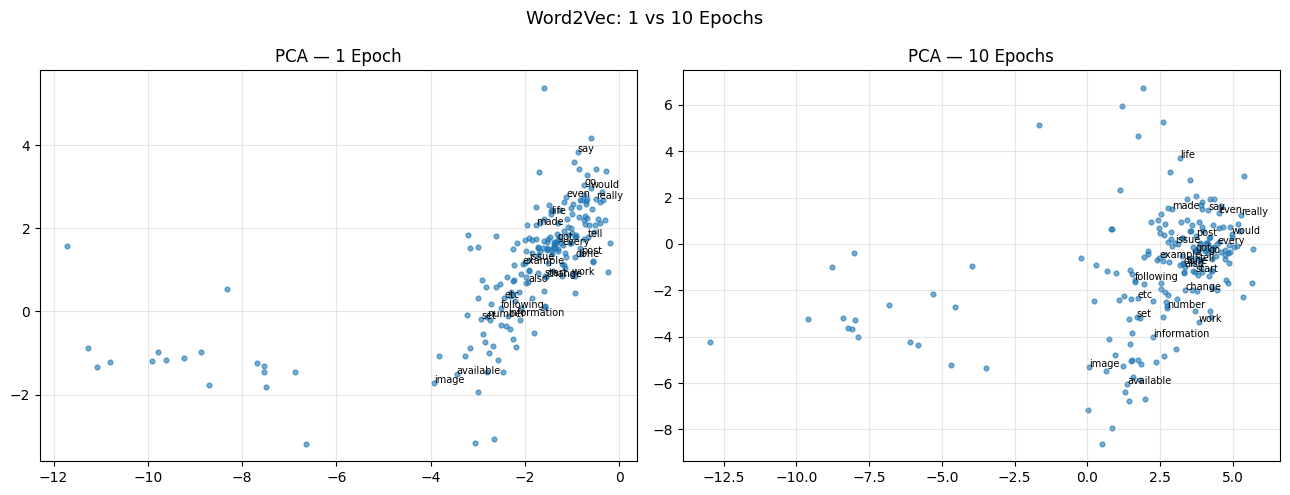

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


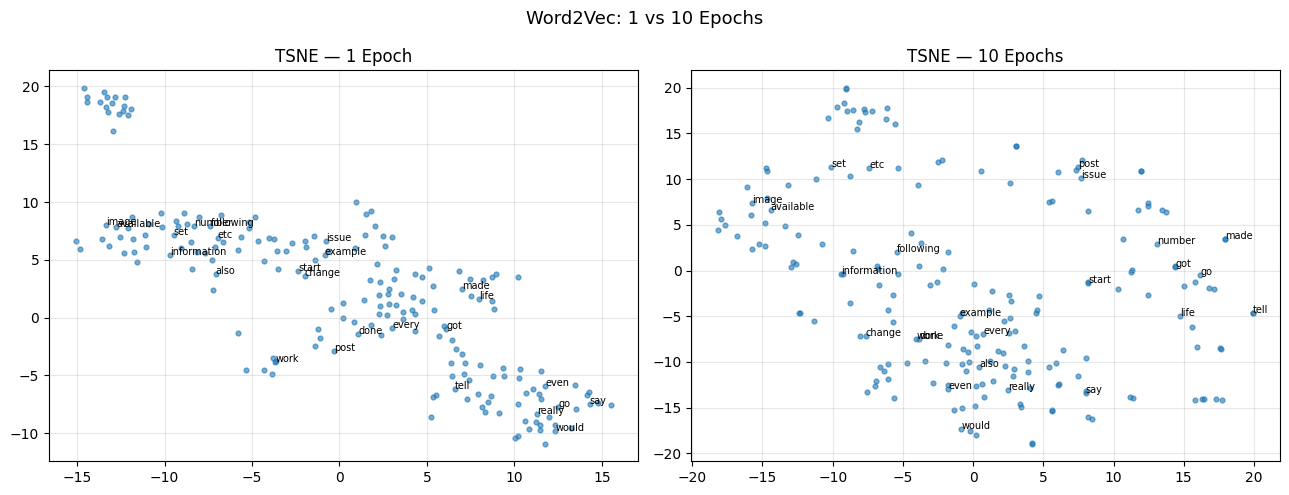

In [ ]:
N = 200
words     = w2v_1.wv.index_to_key[:N]
vecs_1    = np.array([w2v_1.wv[w]  for w in words])
vecs_10   = np.array([w2v_10.wv[w] for w in words])

def plot_side_by_side(vecs1, vecs2, words, method="pca"):
    all_vecs  = np.vstack([vecs1, vecs2])
    reducer   = PCA(n_components=2, random_state=42) if method == "pca" \
                else TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
    projected = reducer.fit_transform(all_vecs)
    p1, p2    = projected[:len(words)], projected[len(words):]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, proj, label in zip(axes, [p1, p2], ["1 Epoch", "10 Epochs"]):
        ax.scatter(proj[:, 0], proj[:, 1], s=12, alpha=0.6)
        for i in range(0, len(words), len(words) // 25):
            ax.annotate(words[i], proj[i], fontsize=7)
        ax.set_title(f"{method.upper()} — {label}")
        ax.grid(alpha=0.3)
    plt.suptitle("Word2Vec: 1 vs 10 Epochs", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"embeddings_{method}.png", dpi=150)
    plt.show()

plot_side_by_side(vecs_1, vecs_10, words, method="pca")
plot_side_by_side(vecs_1, vecs_10, words, method="tsne")

# STEP 5: How much did the vectors shift?

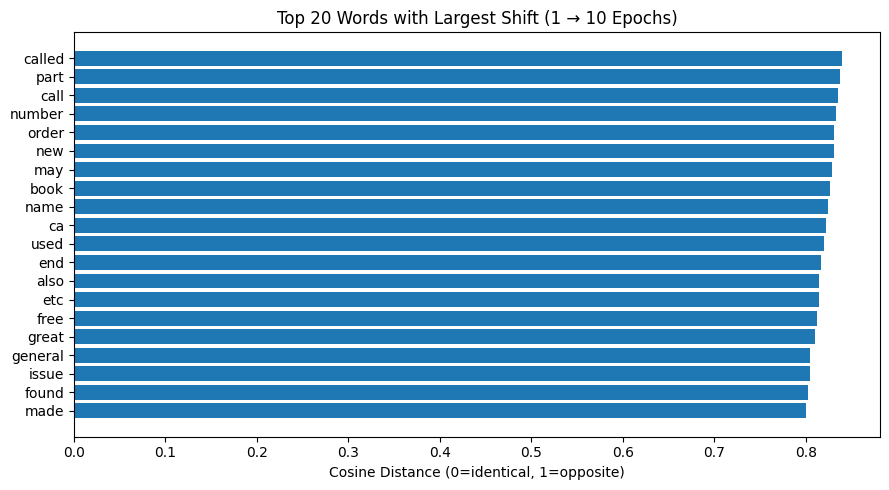

Mean shift: 0.6983


In [ ]:
def cosine_distance(a, b):
    return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

shifts   = {w: cosine_distance(w2v_1.wv[w], w2v_10.wv[w]) for w in words}
top20    = sorted(shifts.items(), key=lambda x: x[1], reverse=True)[:20]
top_w, top_v = zip(*top20)

plt.figure(figsize=(9, 5))
plt.barh(top_w[::-1], top_v[::-1])
plt.xlabel("Cosine Distance (0=identical, 1=opposite)")
plt.title("Top 20 Words with Largest Shift (1 → 10 Epochs)")
plt.tight_layout()
plt.savefig("cosine_shift.png", dpi=150)
plt.show()

print(f"Mean shift: {np.mean(list(shifts.values())):.4f}")

# STEP 6: Define the Neural Network

## Architecture (fixed by assignment):
##   Linear → ReLU → Linear
## Input:  100-dimensional Word2Vec vector
## Output: 20 class scores (one per newsgroup)

In [ ]:
class Classifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, 256)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(256, 20)

    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))


def train_and_evaluate(X_train, X_test, y_train, y_test, input_dim, run_name):
    EPOCHS, BATCH_SIZE, LR = 20, 64, 0.001

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TensorDataset(torch.tensor(X_test),  torch.tensor(y_test)),  batch_size=BATCH_SIZE)

    model     = Classifier(input_dim)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    wandb.init(project="nalapro-20newsgroups", name=run_name,
               config={"epochs": EPOCHS, "lr": LR, "input_dim": input_dim}, reinit=True)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        # Train
        model.train()
        t_loss, t_correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * len(yb)
            t_correct += (out.argmax(1) == yb).sum().item()
            total     += len(yb)
        t_loss /= total;  t_acc = t_correct / total

        # Validate
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                out   = model(xb)
                loss  = criterion(out, yb)
                v_loss    += loss.item() * len(yb)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_total   += len(yb)
        v_loss /= v_total;  v_acc = v_correct / v_total

        wandb.log({"epoch": epoch, "train_loss": t_loss, "train_acc": t_acc,
                                   "val_loss":   v_loss, "val_acc":   v_acc})
        for k, v in zip(history, [t_loss, v_loss, t_acc, v_acc]):
            history[k].append(v)

        print(f"  [{run_name}] Epoch {epoch:2d} | train_loss={t_loss:.3f} acc={t_acc:.3f} | val_loss={v_loss:.3f} acc={v_acc:.3f}")

    # Final test evaluation
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            preds.extend(model(xb).argmax(1).numpy())

    acc = accuracy_score(y_test, preds)
    print(f"\n  Final accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=test_data.target_names, zero_division=0))

    wandb.log({"final_test_accuracy": acc})
    wandb.finish()
    return history, acc

#Experiment 1: Word2Vec (Task 1b)

In [ ]:
def mean_vector(tokens, wv):
    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

X_train_w2v = np.array([mean_vector(t, w2v_10.wv) for t in train_tokens], dtype=np.float32)
X_test_w2v  = np.array([mean_vector(t, w2v_10.wv) for t in test_tokens],  dtype=np.float32)

history_w2v, acc_w2v = train_and_evaluate(
    X_train_w2v, X_test_w2v, train_data.target, test_data.target,
    input_dim=100, run_name="word2vec"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gichukicynthia (gichukicynthia-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [word2vec] Epoch  1 | train_loss=1.920 acc=0.436 | val_loss=1.545 acc=0.517
  [word2vec] Epoch  2 | train_loss=1.418 acc=0.556 | val_loss=1.464 acc=0.545
  [word2vec] Epoch  3 | train_loss=1.335 acc=0.583 | val_loss=1.424 acc=0.559
  [word2vec] Epoch  4 | train_loss=1.286 acc=0.599 | val_loss=1.405 acc=0.565
  [word2vec] Epoch  5 | train_loss=1.250 acc=0.610 | val_loss=1.402 acc=0.566
  [word2vec] Epoch  6 | train_loss=1.223 acc=0.617 | val_loss=1.393 acc=0.574
  [word2vec] Epoch  7 | train_loss=1.197 acc=0.628 | val_loss=1.379 acc=0.575
  [word2vec] Epoch  8 | train_loss=1.175 acc=0.629 | val_loss=1.381 acc=0.582
  [word2vec] Epoch  9 | train_loss=1.159 acc=0.633 | val_loss=1.382 acc=0.584
  [word2vec] Epoch 10 | train_loss=1.136 acc=0.641 | val_loss=1.392 acc=0.572
  [word2vec] Epoch 11 | train_loss=1.119 acc=0.647 | val_loss=1.384 acc=0.580
  [word2vec] Epoch 12 | train_loss=1.104 acc=0.651 | val_loss=1.394 acc=0.575
  [word2vec] Epoch 13 | train_loss=1.088 acc=0.652 | val_loss=1.

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
final_test_accuracy,▁
train_acc,▁▄▅▆▆▆▆▇▇▇▇▇▇▇██████
train_loss,█▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▄▅▆▆▇▇██▇▇▇█▇█▇▇▇█▇
val_loss,█▅▃▂▂▂▁▁▁▂▁▂▁▂▂▂▂▂▂▃
epoch,20
final_test_accuracy,0.57714
train_acc,0.6804
train_loss,0.98578
val_acc,0.57714


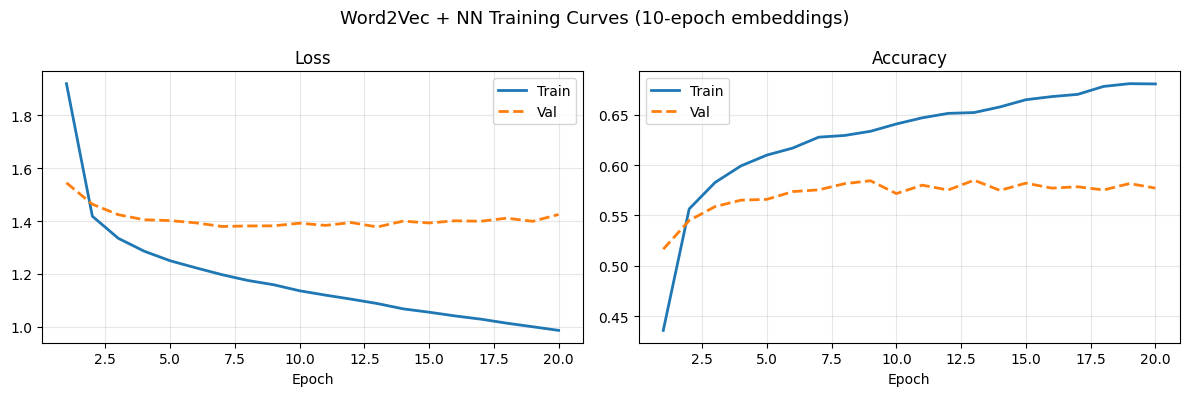

In [ ]:
epochs = range(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history_w2v["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs, history_w2v["val_loss"],   label="Val",   linewidth=2, linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_w2v["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs, history_w2v["val_acc"],   label="Val",   linewidth=2, linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Word2Vec + NN Training Curves (10-epoch embeddings)", fontsize=13)
plt.tight_layout()
plt.savefig("word2vec_training_curves.png", dpi=150)
plt.show()

## Experiment 2: TF-IDF (Task 1c)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_data.data).toarray().astype(np.float32)
X_test_tfidf  = tfidf.transform(test_data.data).toarray().astype(np.float32)

history_tfidf, acc_tfidf = train_and_evaluate(
    X_train_tfidf, X_test_tfidf, train_data.target, test_data.target,
    input_dim=5000, run_name="tfidf"
)

  [tfidf] Epoch  1 | train_loss=2.373 acc=0.471 | val_loss=1.667 acc=0.629
  [tfidf] Epoch  2 | train_loss=1.114 acc=0.753 | val_loss=1.213 acc=0.662
  [tfidf] Epoch  3 | train_loss=0.699 acc=0.833 | val_loss=1.133 acc=0.668
  [tfidf] Epoch  4 | train_loss=0.487 acc=0.888 | val_loss=1.129 acc=0.662
  [tfidf] Epoch  5 | train_loss=0.351 acc=0.927 | val_loss=1.150 acc=0.662
  [tfidf] Epoch  6 | train_loss=0.261 acc=0.951 | val_loss=1.185 acc=0.654
  [tfidf] Epoch  7 | train_loss=0.203 acc=0.963 | val_loss=1.230 acc=0.654
  [tfidf] Epoch  8 | train_loss=0.167 acc=0.968 | val_loss=1.270 acc=0.646
  [tfidf] Epoch  9 | train_loss=0.144 acc=0.970 | val_loss=1.311 acc=0.648
  [tfidf] Epoch 10 | train_loss=0.129 acc=0.972 | val_loss=1.351 acc=0.647
  [tfidf] Epoch 11 | train_loss=0.118 acc=0.972 | val_loss=1.386 acc=0.644
  [tfidf] Epoch 12 | train_loss=0.111 acc=0.972 | val_loss=1.421 acc=0.642
  [tfidf] Epoch 13 | train_loss=0.107 acc=0.972 | val_loss=1.449 acc=0.639
  [tfidf] Epoch 14 | trai

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
final_test_accuracy,▁
train_acc,▁▅▆▇▇███████████████
train_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▇█▇▇▅▅▄▄▄▄▃▃▃▃▂▂▂▃▂
val_loss,█▂▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇█
epoch,20
final_test_accuracy,0.63502
train_acc,0.9726
train_loss,0.09348
val_acc,0.63502


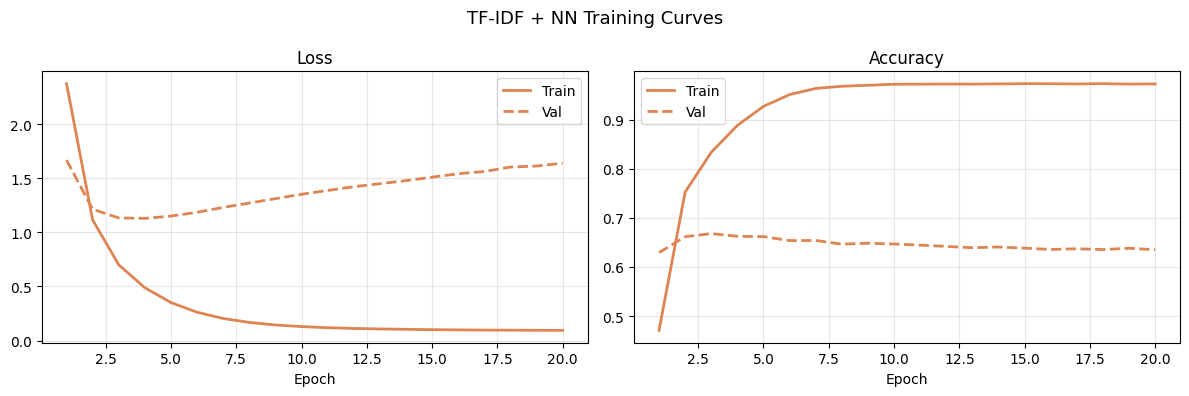

In [ ]:
epochs = range(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history_tfidf["train_loss"], label="Train", linewidth=2, color="#DD8452")
axes[0].plot(epochs, history_tfidf["val_loss"],   label="Val",   linewidth=2, linestyle="--", color="#DD8452")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_tfidf["train_acc"], label="Train", linewidth=2, color="#DD8452")
axes[1].plot(epochs, history_tfidf["val_acc"],   label="Val",   linewidth=2, linestyle="--", color="#DD8452")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("TF-IDF + NN Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("tfidf_training_curves.png", dpi=150)
plt.show()

## Experiment 3: TF-IDF + Bigrams + LSA *(Task 1d)*
- **Bigrams** capture two-word phrases (e.g. "not good" vs "not" + "good")
- **LSA** compresses 20k sparse dimensions → 300 dense dimensions, grouping semantically similar words

In [ ]:
tfidf_bi = TfidfVectorizer(max_features=20000, sublinear_tf=True, ngram_range=(1, 2))
X_bi     = tfidf_bi.fit_transform(train_data.data)
X_bi_te  = tfidf_bi.transform(test_data.data)

lsa             = TruncatedSVD(n_components=300, random_state=42)
X_train_lsa     = lsa.fit_transform(X_bi).astype(np.float32)
X_test_lsa      = lsa.transform(X_bi_te).astype(np.float32)

print(f"Variance explained by 300 components: {lsa.explained_variance_ratio_.sum():.1%}")

history_lsa, acc_lsa = train_and_evaluate(
    X_train_lsa, X_test_lsa, train_data.target, test_data.target,
    input_dim=300, run_name="tfidf-bigrams-lsa"
)

Variance explained by 300 components: 21.4%


  [tfidf-bigrams-lsa] Epoch  1 | train_loss=2.864 acc=0.355 | val_loss=2.624 acc=0.516
  [tfidf-bigrams-lsa] Epoch  2 | train_loss=2.063 acc=0.629 | val_loss=1.816 acc=0.595
  [tfidf-bigrams-lsa] Epoch  3 | train_loss=1.410 acc=0.680 | val_loss=1.487 acc=0.616
  [tfidf-bigrams-lsa] Epoch  4 | train_loss=1.165 acc=0.701 | val_loss=1.369 acc=0.619
  [tfidf-bigrams-lsa] Epoch  5 | train_loss=1.052 acc=0.712 | val_loss=1.313 acc=0.623
  [tfidf-bigrams-lsa] Epoch  6 | train_loss=0.985 acc=0.720 | val_loss=1.288 acc=0.625
  [tfidf-bigrams-lsa] Epoch  7 | train_loss=0.939 acc=0.728 | val_loss=1.273 acc=0.623
  [tfidf-bigrams-lsa] Epoch  8 | train_loss=0.907 acc=0.731 | val_loss=1.267 acc=0.623
  [tfidf-bigrams-lsa] Epoch  9 | train_loss=0.880 acc=0.737 | val_loss=1.262 acc=0.625
  [tfidf-bigrams-lsa] Epoch 10 | train_loss=0.857 acc=0.743 | val_loss=1.271 acc=0.624
  [tfidf-bigrams-lsa] Epoch 11 | train_loss=0.840 acc=0.746 | val_loss=1.276 acc=0.619
  [tfidf-bigrams-lsa] Epoch 12 | train_loss

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
final_test_accuracy,▁
train_acc,▁▆▆▇▇▇▇▇▇███████████
train_loss,█▅▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▆▇█████████████▇▇▇▇
val_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
final_test_accuracy,0.61445
train_acc,0.7717
train_loss,0.74419
val_acc,0.61445


## Results Comparison

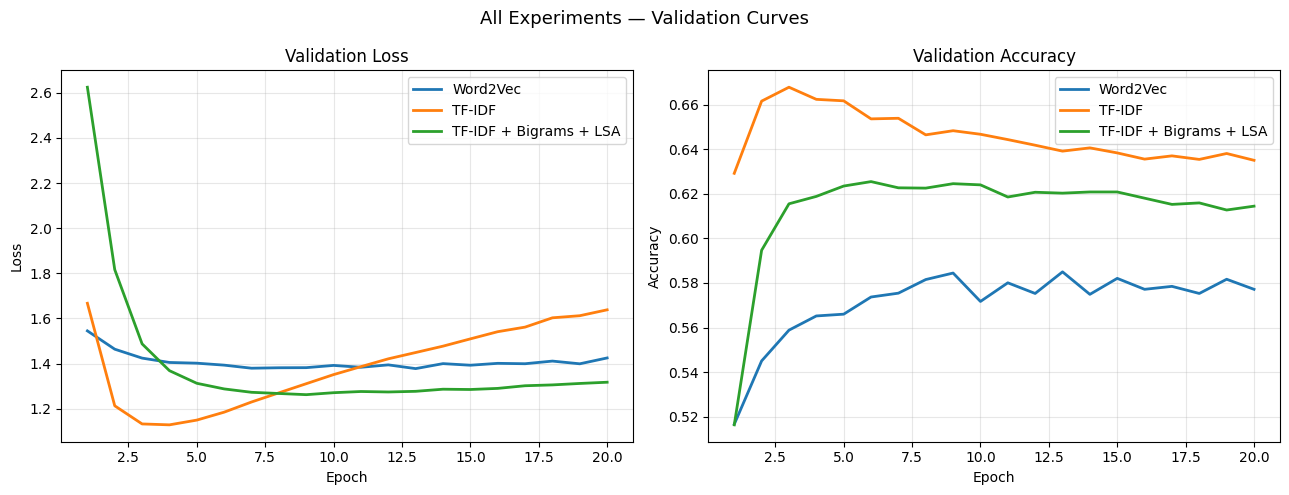

In [ ]:
epochs = range(1, 21)
runs   = [("Word2Vec", history_w2v), ("TF-IDF", history_tfidf), ("TF-IDF + Bigrams + LSA", history_lsa)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, h in runs:
    axes[0].plot(epochs, h["val_loss"], label=label, linewidth=2)
    axes[1].plot(epochs, h["val_acc"],  label=label, linewidth=2)

for ax, title, ylabel in zip(axes, ["Validation Loss", "Validation Accuracy"], ["Loss", "Accuracy"]):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("All Experiments — Validation Curves", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_curves.png", dpi=150)
plt.show()

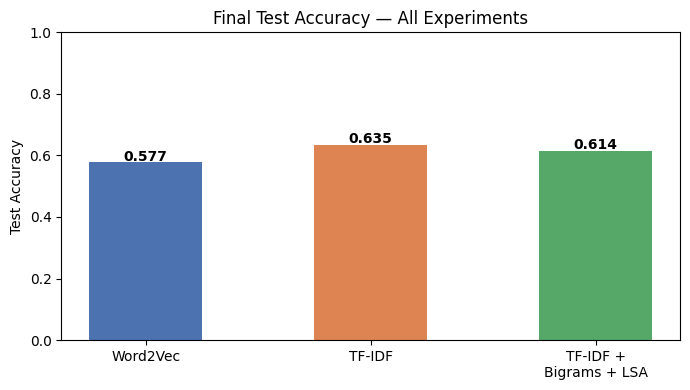


Summary:
  Word2Vec                      : 0.5771
  TF-IDF                        : 0.6350
  TF-IDF + Bigrams + LSA        : 0.6144


In [ ]:
labels = ["Word2Vec", "TF-IDF", "TF-IDF +\nBigrams + LSA"]
accs   = [acc_w2v, acc_tfidf, acc_lsa]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, accs, color=["#4C72B0", "#DD8452", "#55A868"], width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{acc:.3f}", ha="center", fontweight="bold")
plt.ylim(0, 1); plt.ylabel("Test Accuracy")
plt.title("Final Test Accuracy — All Experiments")
plt.tight_layout()
plt.savefig("final_accuracy.png", dpi=150)
plt.show()

print("\nSummary:")
for label, acc in zip(labels, accs):
    print(f"  {label.replace(chr(10), ' '):30s}: {acc:.4f}")

In [ ]:
# model.eval()
# all_preds = []
# with torch.no_grad():
#     for X_batch, _ in test_loader:
#         all_preds.extend(model(X_batch).argmax(1).numpy())

# final_acc = accuracy_score(y_test, all_preds)
# print(f"\nFinal Test Accuracy: {final_acc:.4f}")
# print(classification_report(y_test, all_preds,
#                              target_names=test_data.target_names, zero_division=0))

# wandb.log({"final_test_accuracy": final_acc})
# wandb.finish()